In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models, optimizers, applications
from tensorflow.keras import backend as K
from tensorflow.keras import Input, Model, Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    Flatten,
    Conv2D,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Input
)

from tensorflow.keras.optimizers import Adam, SGD

from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    LearningRateScheduler,
    TensorBoard
)

In [19]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/cifar10/cifar10/train",
    image_size=(32, 32),
    batch_size=32,
    label_mode="categorical"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/cifar10/cifar10/test",
    image_size=(32, 32),
    batch_size=32,
    label_mode="categorical"
)


Found 50000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.


In [20]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])


In [21]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications.resnet_v2 import ResNet50V2, preprocess_input
from tensorflow.keras import backend as K

base_model = ResNet50V2(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)
)



# model = models.Sequential([
#     layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
#     layers.MaxPooling2D(2,2),

#     layers.Conv2D(64, (3,3), activation='relu'),
#     layers.MaxPooling2D(2,2),

#     layers.Conv2D(128, (3,3), activation='relu'),
#     layers.Flatten(),

#     layers.Dense(128, activation='relu'),
#     layers.Dense(10, activation='softmax')  # 10 CIFAR classes
# ])


In [22]:
base_model.trainable = True

# Freeze BatchNorm layers
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Freeze lower layers, train top 20
for layer in base_model.layers[:-20]:
    layer.trainable = False


In [ ]:
model = models.Sequential([
    data_augmentation,
    layers.Resizing(128, 128),

    layers.Lambda(preprocess_input),

    base_model,

    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),

    layers.Dense(512, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(10, activation="softmax")
])


In [25]:
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-6
)


In [26]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(3e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)



history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 46ms/step - accuracy: 0.3729 - loss: 2.0082 - val_accuracy: 0.8265 - val_loss: 0.5182 - learning_rate: 3.0000e-05
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.6651 - loss: 1.0098 - val_accuracy: 0.8486 - val_loss: 0.4487 - learning_rate: 3.0000e-05
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.7137 - loss: 0.8656 - val_accuracy: 0.8542 - val_loss: 0.4356 - learning_rate: 3.0000e-05
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.7402 - loss: 0.7816 - val_accuracy: 0.8690 - val_loss: 0.3851 - learning_rate: 3.0000e-05
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.7578 - loss: 0.7300 - val_accuracy: 0.8718 - val_loss: 0.3794 - learning_rate: 3.0000e-05
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.7764 - loss: 0.6761 - val_accuracy: 0.8757 - val_loss: 0.3721 - learning_rate: 3.0000e-05
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━

In [27]:
model.evaluate(test_ds)


313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.9034 - loss: 0.2843


[0.2893175184726715, 0.9035999774932861]

In [31]:
model.save('Umang_CIFAR10.keras')

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

In [33]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.append(preds)
    y_true.append(labels.numpy())

y_true = np.vstack(y_true)
y_pred = np.vstack(y_pred)
n_classes = 10


In [34]:
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])


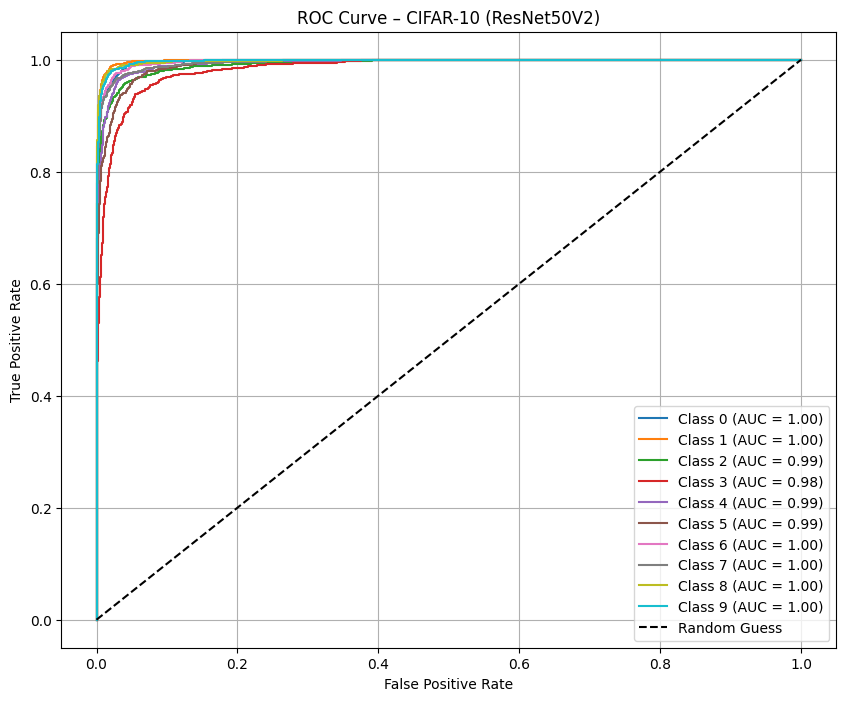

In [35]:
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"Class {i} (AUC = {roc_auc[i]:.2f})"
    )

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – CIFAR-10 (ResNet50V2)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [36]:
fpr_micro, tpr_micro, _ = roc_curve(
    y_true.ravel(),
    y_pred.ravel()
)
roc_auc_micro = auc(fpr_micro, tpr_micro)


In [37]:
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= n_classes

roc_auc_macro = auc(all_fpr, mean_tpr)


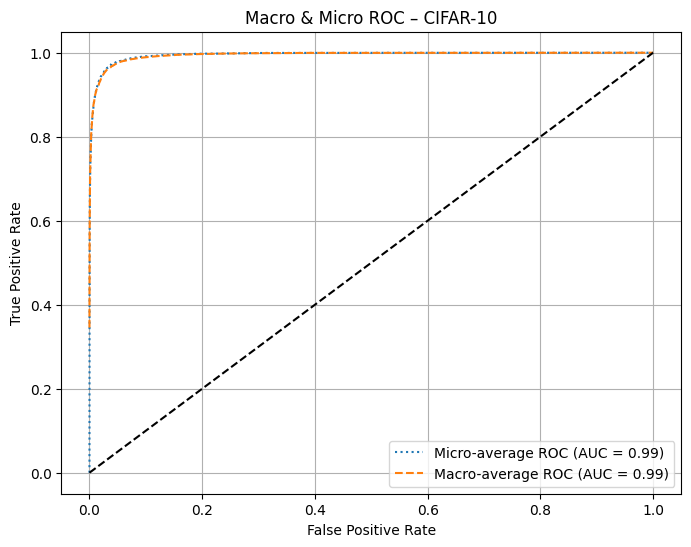

In [38]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_micro, tpr_micro,
    label=f"Micro-average ROC (AUC = {roc_auc_micro:.2f})",
    linestyle=":"
)

plt.plot(
    all_fpr, mean_tpr,
    label=f"Macro-average ROC (AUC = {roc_auc_macro:.2f})",
    linestyle="--"
)

plt.plot([0, 1], [0, 1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Macro & Micro ROC – CIFAR-10")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [41]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.append(np.argmax(preds, axis=1))
    y_true.append(np.argmax(labels.numpy(), axis=1))

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)


In [42]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)
print(cm)


[[902   7  23   1  10   1   4   5  36  11]
 [  3 951   0   0   1   0   0   0   5  40]
 [  8   0 881  16  40  10  33  11   1   0]
 [ 10   3  24 747  24 106  61  13   5   7]
 [  0   1  14  11 903  16  27  26   2   0]
 [  2   1   3  59  13 887  18  17   0   0]
 [  2   2  10   9  11   6 958   1   0   1]
 [  4   0   9  14  25  25   9 912   0   2]
 [ 17   6   2   0   1   4   2   0 955  13]
 [  9  39   1   1   0   0   1   2   7 940]]


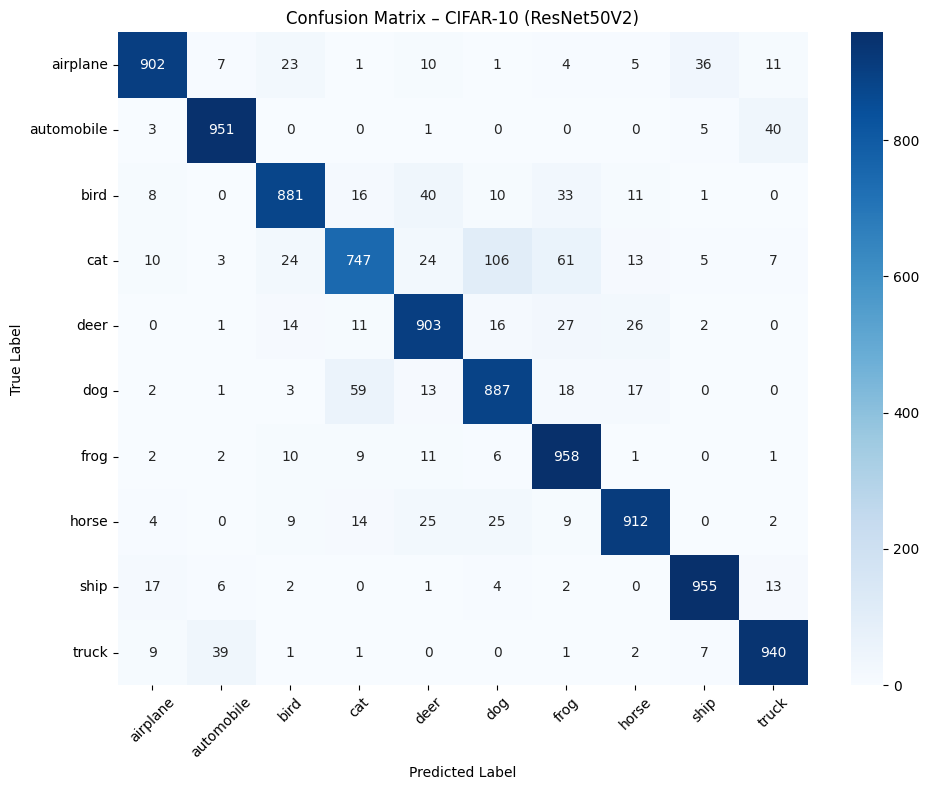

In [44]:
import seaborn as sns
class_names = test_ds.class_names

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – CIFAR-10 (ResNet50V2)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
